# D1 — DoorKey-6×6 belief decoding

论文定位：标准 Dreamer actor/critic 使用完整 1280 维连续 belief；100 局 same-generator 轨迹按 episode 划分为 70/15/15，线性 probe 与离线 N-DNF 读取九个 DoorKey 谓词。

本验收包含两个真实闭环动画（同一个论文 D1 checkpoint，同一个 actor，没有任何后验动作蒸馏）：

1. **原始 Dreamer actor** 自己走迷宫。
2. 同一条 rollout，逐帧把连续 belief **蒸馏**成九个具名谓词（线性 probe，episode-disjoint train/test），与走迷宫画面同步显示。

边界：D1 证明 episode-disjoint decodability；不证明 baseline actor 使用这些谓词，也不证明 unseen-layout generalisation。

In [1]:
import argparse, json, pathlib, sys, tempfile, warnings
warnings.filterwarnings("ignore")
import numpy as np
import torch
import matplotlib
matplotlib.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DengXian"]
matplotlib.rcParams["axes.unicode_minus"] = False
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

HERE = pathlib.Path.cwd()
REPO = HERE if (HERE / "dreamer.py").exists() else HERE.parent
sys.path[:0] = [str(REPO), str(REPO / "scripts")]

MODEL_PATH = REPO / "models/doorkey/doorkey_experiment_1_d1/checkpoint.pt"
RESULT_PATH = REPO / "results/doorkey_experiment_1_d1/d1_unified.json"
TRAJ_PATH = REPO / "results/doorkey_experiment_1_d1/trajectory.npz"
CONFIG_PATH = REPO / "models/doorkey/doorkey_experiment_1_d1/config.yaml"
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
for path in (MODEL_PATH, RESULT_PATH, TRAJ_PATH, CONFIG_PATH):
    assert path.exists(), path
paper = json.loads(RESULT_PATH.read_text(encoding="utf-8"))
print("device:", DEVICE)
print("checkpoint:", MODEL_PATH.relative_to(REPO))
print("paper task result:", paper["task"])
print("split sizes:", {k: len(v) for k, v in paper["protocol"]["episode_split"].items()})

device: cuda:0
checkpoint: models\doorkey\doorkey_experiment_1_d1\checkpoint.pt
paper task result: {'success_rate': 1.0, 'successes': 100, 'episodes': 100, 'mean_length': 12.77}
split sizes: {'train': 70, 'validation': 15, 'test': 15}


In [2]:
import ruamel.yaml as yaml
import dreamer, tools
import envs.minigrid as M
import envs.wrappers as wrappers

def recursive_update(base, update):
    for key, value in update.items():
        if isinstance(value, dict) and key in base:
            recursive_update(base[key], value)
        else:
            base[key] = value

groups = yaml.safe_load((REPO / "configs.yaml").read_text(encoding="utf-8"))
values = {}
for name in ["defaults", "minigrid"]:
    recursive_update(values, groups[name])
parser = argparse.ArgumentParser()
for key, value in sorted(values.items()):
    kind = tools.args_type(value)
    parser.add_argument(f"--{key}", type=kind, default=kind(value))
config = parser.parse_args([])
config.device = DEVICE
config.num_actions = 5
config.compile = False

base = M.MiniGrid("doorkey6x6", mode="eval", seed=0, max_steps=config.time_limit)
act_space = wrappers.OneHotAction(base).action_space
obs_space = base.observation_space
base.close()
logger = tools.Logger(pathlib.Path(tempfile.mkdtemp()), 0)
agent = dreamer.Dreamer(obs_space, act_space, config, logger, dataset=None).to(DEVICE)
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
missing, unexpected = agent.load_state_dict(checkpoint["agent_state_dict"])
assert not missing and not unexpected
agent.requires_grad_(False)
agent.eval()
wm, behavior = agent._wm, agent._task_behavior
print(f"loaded D1 agent: {sum(p.numel() for p in agent.parameters()):,} parameters")
print("policy input: continuous 1280-D RSSM feature")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Encoder CNN shapes: {}
Encoder MLP shapes: {'grid': (148,)}
Decoder CNN shapes: {}
Decoder MLP shapes: {'grid': (148,)}


Optimizer model_opt has 12456852 variables.
Optimizer actor_opt has 395525 variables.
Optimizer value_opt has 459775 variables.
loaded D1 agent: 13,771,927 parameters
policy input: continuous 1280-D RSSM feature


In [3]:
@torch.no_grad()
def rollout(seed, render=False):
    env = M.MiniGrid("doorkey6x6", mode="eval", seed=seed, max_steps=config.time_limit)
    obs = env.reset()
    latent = action = None
    frames, actions, feats = [], [], []
    success = False
    for step in range(config.time_limit):
        batch = {k: np.asarray(v)[None] for k, v in obs.items() if not k.startswith("log_")}
        data = wm.preprocess(batch)
        embed = wm.encoder(data)
        latent, _ = wm.dynamics.obs_step(latent, action, embed, data["is_first"], sample=False)
        feat = wm.dynamics.get_feat(latent)
        action = behavior.actor(feat).mode()
        action_index = int(torch.argmax(action, dim=-1)[0].item())
        if render:
            frames.append(env.render())
            actions.append(action_index)
            feats.append(feat[0].detach().cpu().numpy())
        obs, reward, done, _ = env.step(action_index)
        if done:
            success = bool(reward > 0)
            break
    if render:
        frames.append(env.render())
        feats.append(feat[0].detach().cpu().numpy())
    env.close()
    return {"success": success, "steps": step + 1, "frames": frames, "actions": actions, "feats": feats}

ACTION_NAMES = ["left", "right", "forward", "pickup", "toggle"]
def show_maze_animation(run, title):
    fig, ax = plt.subplots(figsize=(5.2, 5.2))
    image = ax.imshow(run["frames"][0])
    ax.axis("off")
    label = ax.set_title(title)
    def update(i):
        image.set_data(run["frames"][i])
        action = ACTION_NAMES[run["actions"][i]] if i < len(run["actions"]) else "terminal"
        label.set_text(f"{title} | step={i} | action={action}")
        return image, label
    anim = animation.FuncAnimation(fig, update, frames=len(run["frames"]), interval=450, blit=False)
    html = HTML(anim.to_jshtml())
    plt.close(fig)
    return html

## A. 原始 D1 Dreamer actor 走迷宫

In [4]:
original_live = [rollout(seed) for seed in range(20)]
print(f"live visual check: {sum(x['success'] for x in original_live)}/20")
print(f"frozen paper evidence: {paper['task']['successes']}/{paper['task']['episodes']}, mean length={paper['task']['mean_length']:.2f}")
original_demo = rollout(0, render=True)
print("seed=0:", {k: original_demo[k] for k in ("success", "steps")})
display(show_maze_animation(original_demo, "D1 original Dreamer actor"))

live visual check: 20/20
frozen paper evidence: 100/100, mean length=12.77


seed=0: {'success': True, 'steps': 16}


## B. 论文 D1：九谓词 episode-disjoint 读出结果

In [5]:
labels = ["t_left", "t_right", "wall_ahead", "t_ahead", "has_key", "carrying", "t_reach", "door_locked", "door_open"]
print(f"{'predicate':<15} {'base':>7} {'linear acc/BA':>18} {'hard N-DNF acc/BA':>22}")
for label in labels:
    linear = paper["linear_full_belief"][label]
    hard = paper["ndnf_selected_stoch"][label]["hard_delta_4"]
    print(f"{label:<15} {linear['base_rate']:>7.3f} {linear['accuracy']:>8.3f}/{linear['balanced_accuracy']:.3f} {hard['accuracy']:>12.3f}/{hard['balanced_accuracy']:.3f}")
print("\nExtracted hardened rules:")
for rule in paper["rules"]:
    print(" ", rule)

predicate          base      linear acc/BA      hard N-DNF acc/BA
t_left            0.913    0.969/0.877        0.949/0.892
t_right           0.795    0.964/0.940        0.974/0.947
wall_ahead        0.831    0.990/0.994        0.979/0.951
t_ahead           0.667    0.954/0.954        0.964/0.962
has_key           0.738    1.000/1.000        0.995/0.990
carrying          0.738    1.000/1.000        0.995/0.990
t_reach           0.692    1.000/1.000        0.995/0.992
door_locked       0.559    1.000/1.000        0.995/0.995
door_open         0.559    1.000/1.000        0.995/0.995

Extracted hardened rules:
  has_key :- not z6_31, not z30_13.
  door_locked :- not z6_1.
  door_open :- not z7_31, not z30_13.
  carrying :- not z6_31, not z30_13.
  t_ahead :- not z6_1.
  t_left :- z1_14, z1_22, not z4_2, z6_1, z6_31, z7_31, z8_18, not z9_22, not z9_29, z13_16, z14_24, not z20_24, not z23_1, z31_25.
  t_right :- z1_14, z1_22, not z4_2, z6_1, z6_31, z7_31, z8_18, not z9_22, not z9_29, z13_16

## C. 走迷宫动画：原始 actor 同步蒸馏 belief state

上面的表是论文的 frozen evidence；这里在同一个 70/15/15 episode split 上训练同款线性 probe，套在 section A 那条 seed=0 rollout 上，逐帧把连续 belief 读成九个具名谓词，和走迷宫画面同步显示，直观对应上表数字。走迷宫的是原始 D1 actor 本身，没有另训一个动作克隆。

probe held-out mean accuracy over 9 predicates: 0.986  (per-predicate numbers already in the table above)


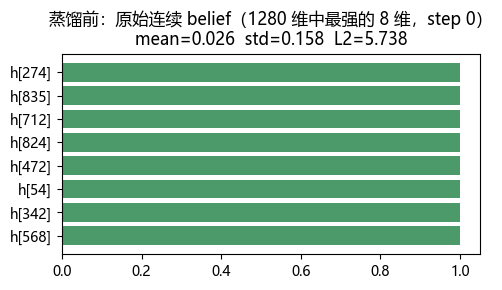

In [6]:
trajectory = np.load(TRAJ_PATH)
split = paper["protocol"]["episode_split"]
train_mask = np.isin(trajectory["episode"], split["train"])
test_mask = np.isin(trajectory["episode"], split["test"])

PRED_LABELS = ["has_key", "door_locked", "door_open", "carrying", "t_ahead", "t_left", "t_right", "t_reach", "wall_ahead"]
belief_probes = {}
for lab in PRED_LABELS:
    y = trajectory[lab].astype(int)
    clf = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=2000))
    clf.fit(trajectory["feat"][train_mask], y[train_mask])
    belief_probes[lab] = clf
mean_acc = np.mean([
    accuracy_score(trajectory[lab].astype(int)[test_mask], belief_probes[lab].predict(trajectory["feat"][test_mask]))
    for lab in PRED_LABELS
])
print(f"probe held-out mean accuracy over 9 predicates: {mean_acc:.3f}  (per-predicate numbers already in the table above)")

# 蒸馏前：走迷宫之前先看一眼这局起始状态的原始连续 belief 长什么样（1280 维，没有任何具名含义）
raw_feat0 = original_demo["feats"][0]
order = np.argsort(-np.abs(raw_feat0))[:8]
fig, ax = plt.subplots(figsize=(5, 3))
ax.barh(range(8), raw_feat0[order][::-1], color="#4c9a6a")
ax.set_yticks(range(8)); ax.set_yticklabels([f"h[{i}]" for i in order[::-1]])
ax.set_title(f"蒸馏前：原始连续 belief（1280 维中最强的 8 维，step 0）\nmean={raw_feat0.mean():.3f}  std={raw_feat0.std():.3f}  L2={np.linalg.norm(raw_feat0):.3f}")
plt.tight_layout(); plt.show()

In [7]:
# 走迷宫动画：左=maze 画面，右=同步蒸馏出的具名 belief state
fig, (axL, axR) = plt.subplots(1, 2, figsize=(10.5, 4.6))
imL = axL.imshow(original_demo["frames"][0]); axL.axis("off")
axR.axis("off")

def belief_panel_d1(i):
    axR.clear(); axR.axis("off")
    feat_i = original_demo["feats"][min(i, len(original_demo["feats"]) - 1)][None]
    axR.text(0.02, 0.97, "蒸馏出的 belief state（线性 probe 读出的具名谓词）:", fontsize=10.5, weight="bold", transform=axR.transAxes)
    for j, lab in enumerate(PRED_LABELS):
        prob = float(belief_probes[lab].predict_proba(feat_i)[0, 1])
        active = prob > 0.5
        color = "#2e7d32" if active else "#999999"
        axR.text(0.05, 0.88 - 0.09 * j, f"{'●' if active else '○'} {lab}  p={prob:.2f}",
                 fontsize=10.5, color=color, transform=axR.transAxes)
    axR.set_xlim(0, 1); axR.set_ylim(0, 1)

def upd_d1(i):
    fr = original_demo["frames"][min(i, len(original_demo["frames"]) - 1)]
    imL.set_data(fr)
    a_idx = original_demo["actions"][i] if i < len(original_demo["actions"]) else None
    axL.set_title(f"step {i}  action={ACTION_NAMES[a_idx] if a_idx is not None else 'terminal'}")
    belief_panel_d1(i)
    return imL,

anim_d1 = animation.FuncAnimation(fig, upd_d1, frames=len(original_demo["frames"]), interval=450, blit=False)
plt.close(fig)
HTML(anim_d1.to_jshtml())

## 验收结论

- 原始 D1 checkpoint 的 live rollout 与冻结 `100/100` 任务证据一致。
- 正式 D1 证据是九谓词在 15 个 episode-disjoint test trajectories（每谓词 195 步）上的 linear / hardened N-DNF 结果；走迷宫动画里同步显示的具名谓词就是这份 probe 的逐帧读出，走迷宫的 actor 本身没有改动。
- D1 不证明 baseline actor 使用九谓词；该问题由 D3 的 atoms-only boundary 与 intervention 单独回答。